# Morning Brews & Morning Rush — Figure Reproduction

**STAT W3106 · Spring 2026
Ramya Subramanian · Sachi Patel · Hailey Gamer

This notebook reproduces all five figures from the blog post.  
Run from the `notebooks/` directory (or adjust the `ROOT` path below).

**Prerequisites:** `torch`, `torch_geometric`, `pandas`, `numpy`, `matplotlib`, `scikit-learn`  
Install via: `pip install torch torch_geometric pandas numpy matplotlib scikit-learn`

---

| Figure | Description |
|--------|-------------|
| Fig 1  | Manhattan hotspot frequency map |
| Fig 2  | Ridership distribution + station graph |
| Fig 3  | SimplifiedGAT architecture diagram |
| Fig 4  | Model comparison (F1 and AUC) |
| Fig 5  | Coffee Contribution Index — diverging barplot |

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

# ── Paths (relative to notebooks/) ───────────────────────────────────────────
ROOT        = ".."                              # project root
META_CSV    = os.path.join(ROOT, "data", "station_metadata.csv")
SUBWAY_CSV  = os.path.join(ROOT, "data", "subway_data_2026.csv")
ADJ_PT      = os.path.join(ROOT, "data", "adjacency_matrix.pt")
CCI_CSV     = os.path.join(ROOT, "data", "cci_scores.csv")
GAT_JSON    = os.path.join(ROOT, "outputs", "gat_results.json")
CCI_PLOT    = os.path.join(ROOT, "outputs", "cci_barplot.png")

# ── Global colour palette ─────────────────────────────────────────────────────
BG      = "#1a0f0a"
TEXT    = "#e8d9c4"
ACCENT  = "#d4924a"
MUTED   = "#7a4f2e"
SUBTEXT = "#a08060"
CREAM   = "#f0e6d3"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "text.color":        TEXT,
    "axes.labelcolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "axes.edgecolor":    SUBTEXT,
    "grid.color":        SUBTEXT,
    "grid.alpha":        0.2,
    "font.family":       "DejaVu Sans",
})

print("Setup complete.")

Setup complete.


## Data Loading

Load station metadata, ridership, adjacency matrix, CCI scores, and GAT results once — all downstream figures draw from these objects.

In [2]:
# Station metadata (123 rows)
meta = pd.read_csv(META_CSV)
meta["station_id"] = meta["station_id"].astype(str)

# Morning ridership (7–10 am, Jan–Apr 2026, 112 dates, 13,759 rows)
df26 = pd.read_csv(SUBWAY_CSV)
df26["date"] = pd.to_datetime(df26["date"])
df26["station_complex_id"] = df26["station_complex_id"].astype(str)

THRESHOLD = df26["morning_ridership"].quantile(0.75)
df26["hotspot"] = (df26["morning_ridership"] >= THRESHOLD).astype(int)
print(f"Hotspot threshold (75th pct): {THRESHOLD:,.0f} riders")
print(f"Hotspot rate: {df26['hotspot'].mean():.1%}  |  Station-days: {len(df26):,}")

# Adjacency matrix
adj = torch.load(ADJ_PT, weights_only=True)
ei  = adj.nonzero(as_tuple=False).numpy()   # (E, 2) edge list
print(f"Graph: {len(meta)} nodes, {(len(ei) // 2):,} undirected edges")

# CCI scores
cci = pd.read_csv(CCI_CSV)
print(f"CCI: {(cci['cci_raw'] > 0).sum()} positive stations, "
      f"{(cci['cci_raw'] < 0).sum()} negative stations")

# GAT results
with open(GAT_JSON) as f:
    gat = json.load(f)
print(f"ST-GAT: F1={gat['test']['f1']:.4f}  AUC={gat['test']['auc']:.4f}")

Hotspot threshold (75th pct): 3,258 riders
Hotspot rate: 25.0%  |  Station-days: 13,759
Graph: 123 nodes, 1,725 undirected edges
CCI: 54 positive stations, 69 negative stations
ST-GAT: F1=0.9062  AUC=0.9885


---
## Figure 1 — Manhattan Hotspot Frequency Map

Each point is a subway station, coloured by the fraction of the 112 days on which it was a hotspot (top-25% morning ridership). The five highest-frequency stations are annotated.

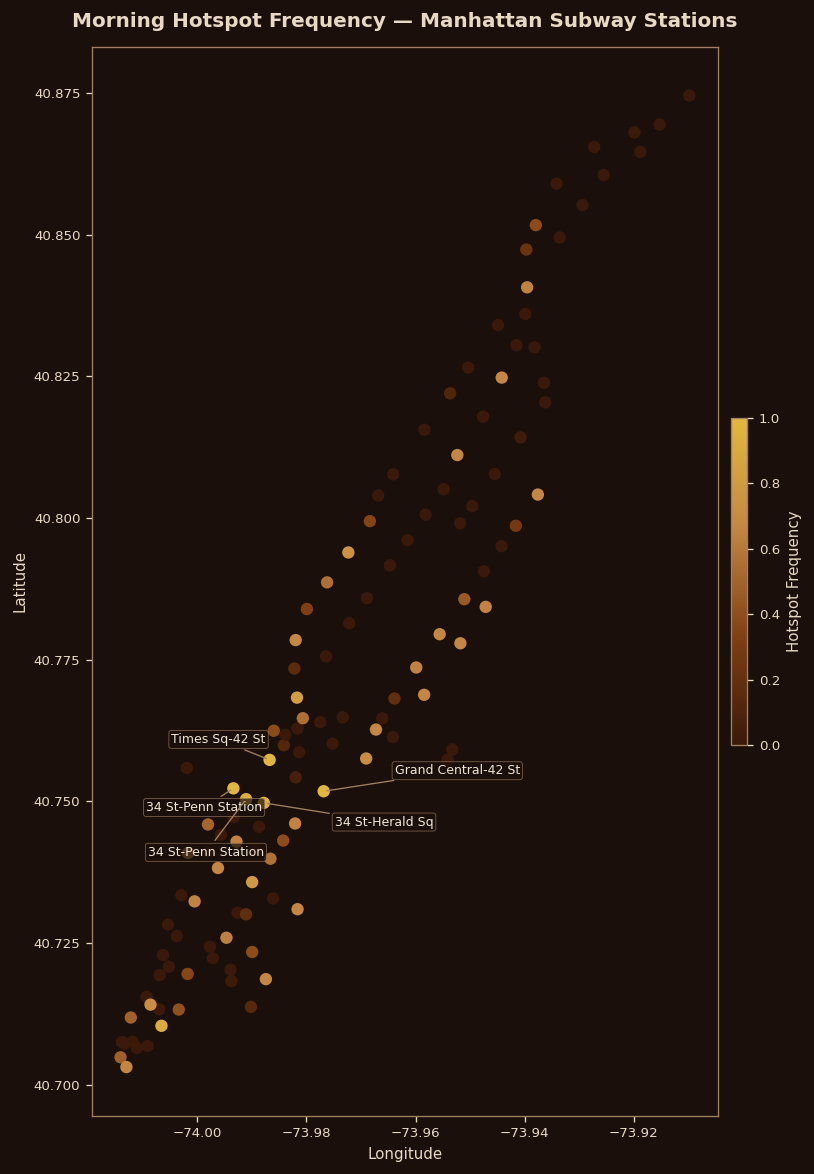

In [3]:
# Compute per-station hotspot frequency
freq = (df26.groupby("station_complex_id")["hotspot"]
            .mean().reset_index()
            .rename(columns={"hotspot": "freq"}))
freq["station_complex_id"] = freq["station_complex_id"].astype(str)
stations = meta.merge(freq, left_on="station_id", right_on="station_complex_id", how="left")
stations["freq"] = stations["freq"].fillna(0)

top5 = stations.nlargest(5, "freq")

cmap = mcolors.LinearSegmentedColormap.from_list(
    "hotspot_warm", ["#3d1a0a", "#8b4513", ACCENT, "#f5c842"], N=256)

fig, ax = plt.subplots(figsize=(7, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sc = ax.scatter(
    stations["lon"], stations["lat"],
    c=stations["freq"], cmap=cmap, vmin=0, vmax=1,
    s=55, zorder=3, edgecolors="none", alpha=0.92
)

# Annotation nudges for top-5 stations
nudges = {
    "611": (-0.018,  0.003),
    "610": ( 0.013,  0.003),
    "164": (-0.016, -0.004),
    "607": ( 0.013, -0.004),
    "318": (-0.018, -0.010),
}
for _, row in top5.iterrows():
    nx, ny = nudges.get(str(row["station_id"]), (0.010, 0.005))
    ax.annotate(
        row["station_name"].split("(")[0].strip(),
        xy=(row["lon"], row["lat"]),
        xytext=(row["lon"] + nx, row["lat"] + ny),
        fontsize=7.5, color=CREAM,
        arrowprops=dict(arrowstyle="-", color=SUBTEXT, lw=0.8),
        bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec=SUBTEXT, alpha=0.7, lw=0.5),
    )

cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Hotspot Frequency", color=TEXT, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT, fontsize=8)
cbar.outline.set_edgecolor(SUBTEXT)

ax.set_title("Morning Hotspot Frequency — Manhattan Subway Stations",
             fontsize=12, color=TEXT, pad=12, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.tick_params(labelsize=8)
for sp in ax.spines.values():
    sp.set_edgecolor(SUBTEXT)

fig.tight_layout(pad=1.5)
plt.show()

---
## Figure 2 — Ridership Distribution + Station Graph

**Left:** Histogram of 7–10am station-day ridership with the hotspot threshold marked.  
**Right:** The spatial graph over 123 stations — edges represent proximity (<1 km) or shared subway line.

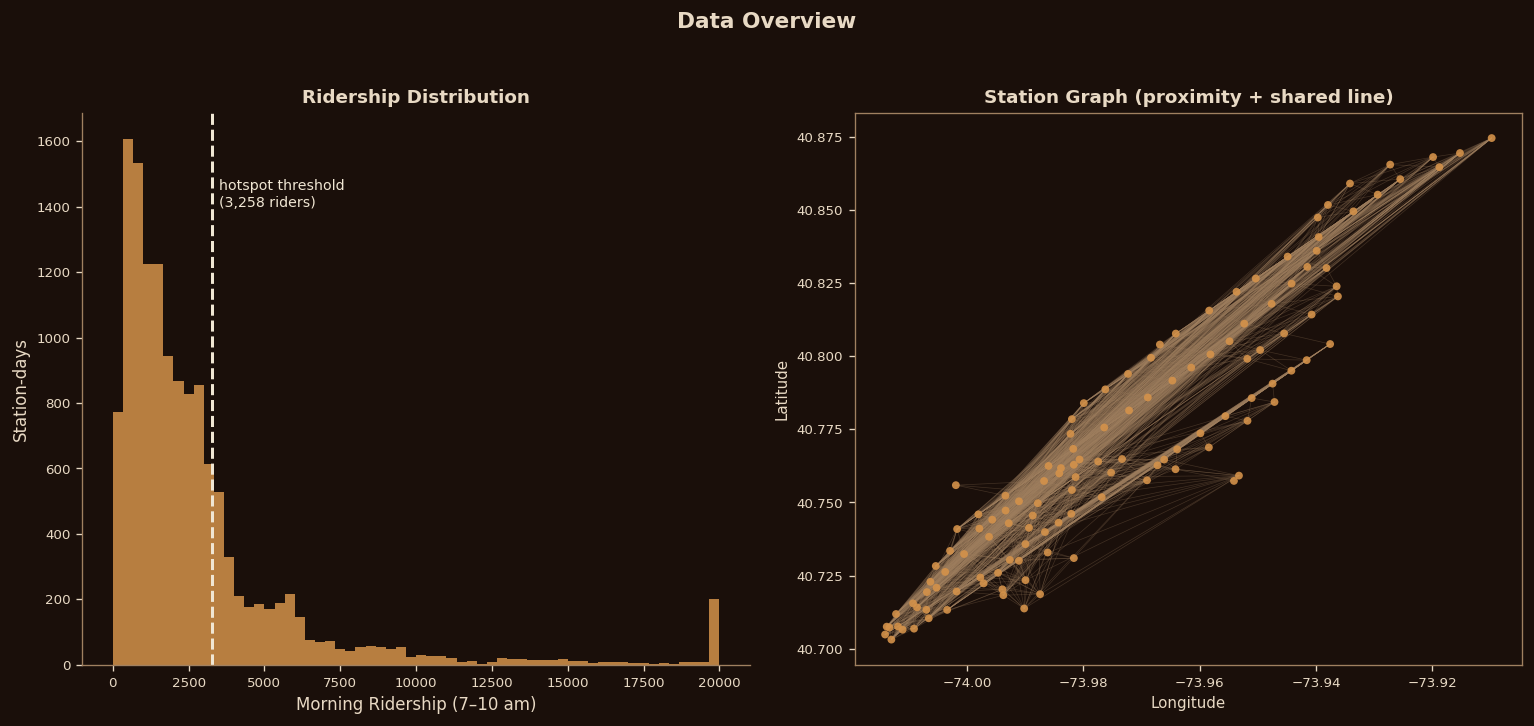

In [4]:
lats = meta["lat"].to_numpy()
lons = meta["lon"].to_numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
for ax in (ax1, ax2):
    ax.set_facecolor(BG)

# ── Left: ridership histogram ─────────────────────────────────────────────────
ridership = df26["morning_ridership"].clip(upper=20000)
ax1.hist(ridership, bins=60, color=ACCENT, alpha=0.85, edgecolor="none")
ax1.axvline(THRESHOLD, color=CREAM, linewidth=1.8, linestyle="--")
ax1.text(THRESHOLD + 250, ax1.get_ylim()[1] * 0.88,
         f"hotspot threshold\n({int(THRESHOLD):,} riders)",
         color=CREAM, fontsize=8.5, va="top")
ax1.set_xlabel("Morning Ridership (7–10 am)", fontsize=10)
ax1.set_ylabel("Station-days", fontsize=10)
ax1.set_title("Ridership Distribution", fontsize=11, color=TEXT, fontweight="bold")
ax1.tick_params(labelsize=8)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
for sp in ["left", "bottom"]:
    ax1.spines[sp].set_edgecolor(SUBTEXT)

# ── Right: station graph ──────────────────────────────────────────────────────
for i, j in ei:
    if i < j:  # undirected — draw each edge once
        ax2.plot([lons[i], lons[j]], [lats[i], lats[j]],
                 color=SUBTEXT, lw=0.4, alpha=0.3, zorder=1)

ax2.scatter(lons, lats, s=22, color=ACCENT, zorder=3, edgecolors="none", alpha=0.9)
ax2.set_title("Station Graph (proximity + shared line)",
              fontsize=11, color=TEXT, fontweight="bold")
ax2.set_xlabel("Longitude", fontsize=9)
ax2.set_ylabel("Latitude", fontsize=9)
ax2.tick_params(labelsize=8)
for sp in ax2.spines.values():
    sp.set_edgecolor(SUBTEXT)

fig.suptitle("Data Overview", fontsize=13, color=TEXT, fontweight="bold", y=1.01)
fig.tight_layout(pad=1.5)
plt.show()

---
## Figure 3 — SimplifiedGAT Architecture Diagram

Drawn entirely in matplotlib using `FancyBboxPatch` and annotate arrows. Shows the three input branches → fusion → two GATConv layers with residual skip → classification head.

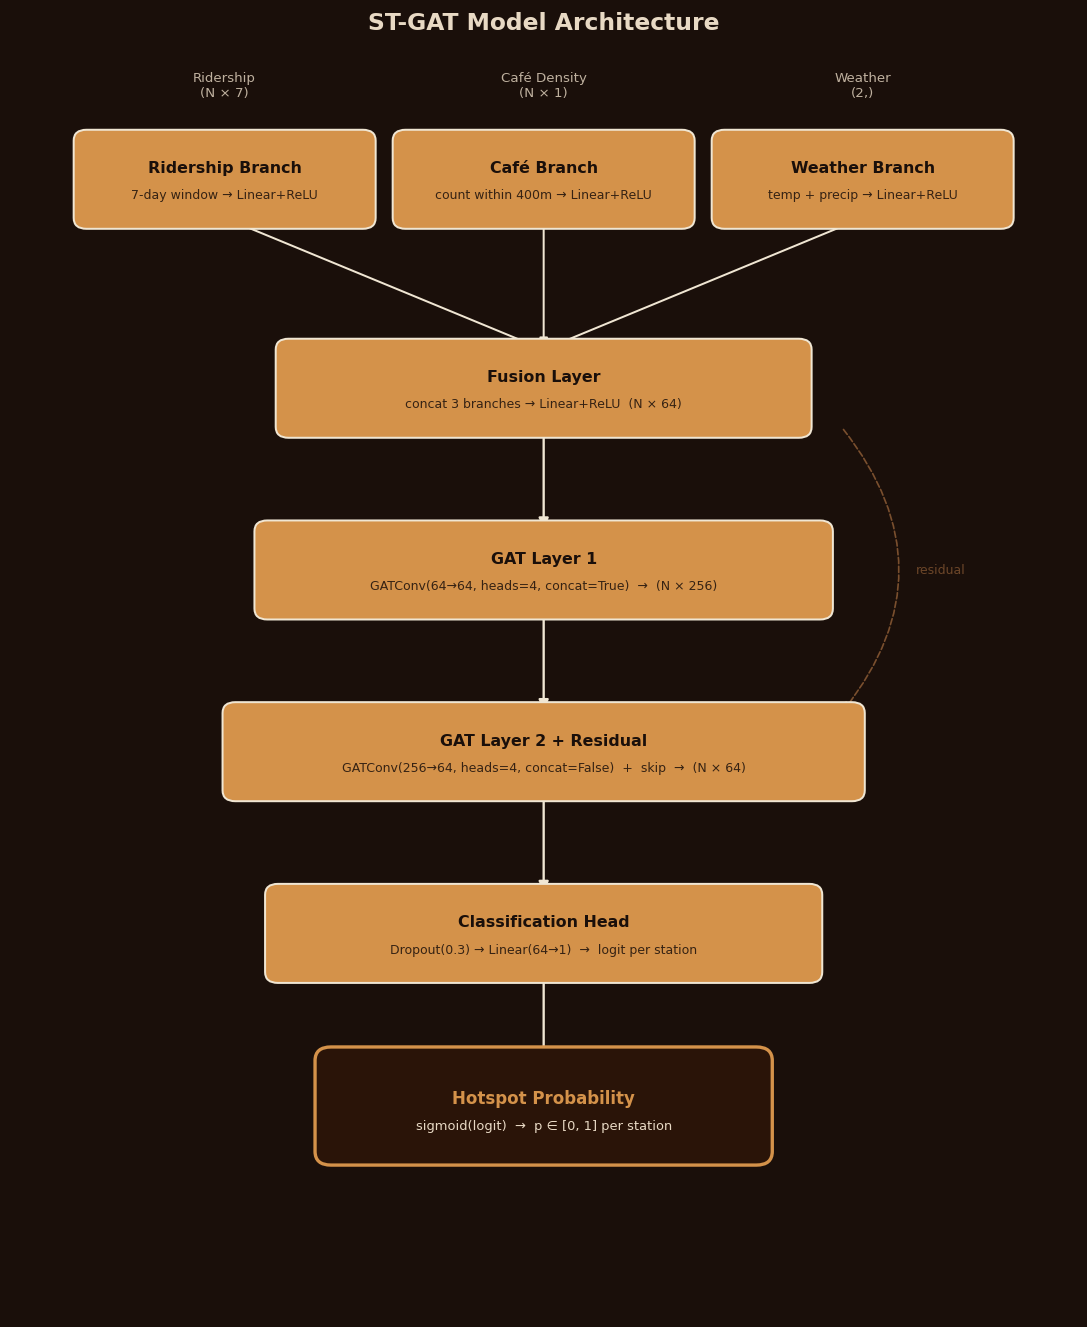

In [5]:
fig, ax = plt.subplots(figsize=(9, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

BOX_W   = 2.6
BOX_H   = 0.85
ARR_CLR = CREAM

def box(cx, cy, label, sublabel=None, w=BOX_W, color=ACCENT):
    patch = FancyBboxPatch(
        (cx - w/2, cy - BOX_H/2), w, BOX_H,
        boxstyle="round,pad=0.12",
        facecolor=color, edgecolor=ARR_CLR, linewidth=1.2, zorder=3
    )
    ax.add_patch(patch)
    y_text = cy + (0.12 if sublabel else 0)
    ax.text(cx, y_text, label, ha="center", va="center",
            fontsize=9.5, color=BG, fontweight="bold", zorder=4)
    if sublabel:
        ax.text(cx, cy - 0.18, sublabel, ha="center", va="center",
                fontsize=7.5, color=BG, alpha=0.85, zorder=4)

def arrow(x1, y1, x2, y2):
    ax.annotate(
        "", xy=(x2, y2 + BOX_H/2), xytext=(x1, y1 - BOX_H/2),
        arrowprops=dict(arrowstyle="-|>", color=ARR_CLR, lw=1.4, mutation_scale=12),
        zorder=2
    )

def fan_arrow(sources_xy, target_cx, target_cy):
    for sx, sy in sources_xy:
        ax.annotate(
            "", xy=(target_cx, target_cy + BOX_H/2),
            xytext=(sx, sy - BOX_H/2),
            arrowprops=dict(
                arrowstyle="-|>", color=ARR_CLR, lw=1.2,
                connectionstyle="arc3,rad=0.0", mutation_scale=10
            ), zorder=2
        )

# Input branches
branch_y = 12.5
branches = [
    (2.0, "Ridership Branch",   "7-day window → Linear+ReLU"),
    (5.0, "Café Branch",        "count within 400m → Linear+ReLU"),
    (8.0, "Weather Branch",     "temp + precip → Linear+ReLU"),
]
for cx, lbl, sub in branches:
    box(cx, branch_y, lbl, sub)

input_labels = ["Ridership\n(N × 7)", "Café Density\n(N × 1)", "Weather\n(2,)"]
for (cx, _, _), inp in zip(branches, input_labels):
    ax.text(cx, branch_y + BOX_H/2 + 0.45, inp,
            ha="center", va="bottom", fontsize=8, color=TEXT, alpha=0.8)

# Fusion
fuse_y = 10.2
fan_arrow([(cx, branch_y) for cx, _, _ in branches], 5.0, fuse_y)
box(5.0, fuse_y, "Fusion Layer",
    "concat 3 branches → Linear+ReLU  (N × 64)", w=4.8)

# GAT 1
gat1_y = 8.2
arrow(5.0, fuse_y, 5.0, gat1_y)
box(5.0, gat1_y, "GAT Layer 1",
    "GATConv(64→64, heads=4, concat=True)  →  (N × 256)", w=5.2)

# GAT 2 + residual
gat2_y = 6.2
arrow(5.0, gat1_y, 5.0, gat2_y)
box(5.0, gat2_y, "GAT Layer 2 + Residual",
    "GATConv(256→64, heads=4, concat=False)  +  skip  →  (N × 64)", w=5.8)

# Residual skip arrow
ax.annotate(
    "", xy=(7.8, gat2_y + BOX_H/2),
    xytext=(7.8, fuse_y - BOX_H/2),
    arrowprops=dict(
        arrowstyle="-|>", color=MUTED, lw=1.0, linestyle="dashed",
        connectionstyle="arc3,rad=-0.4", mutation_scale=10
    ), zorder=2
)
ax.text(8.5, (fuse_y + gat2_y) / 2, "residual",
        fontsize=7.5, color=MUTED, va="center", ha="left", alpha=0.85)

# Classification head
head_y = 4.2
arrow(5.0, gat2_y, 5.0, head_y)
box(5.0, head_y, "Classification Head",
    "Dropout(0.3) → Linear(64→1)  →  logit per station", w=5.0)

# Output
out_y = 2.3
arrow(5.0, head_y, 5.0, out_y)
out_patch = FancyBboxPatch(
    (5.0 - 2.0, out_y - 0.5), 4.0, 1.0,
    boxstyle="round,pad=0.15",
    facecolor="#2a1408", edgecolor=ACCENT, linewidth=2.0, zorder=3
)
ax.add_patch(out_patch)
ax.text(5.0, out_y + 0.08, "Hotspot Probability",
        ha="center", va="center", fontsize=10, color=ACCENT, fontweight="bold", zorder=4)
ax.text(5.0, out_y - 0.22, "sigmoid(logit)  →  p ∈ [0, 1] per station",
        ha="center", va="center", fontsize=7.8, color=TEXT, zorder=4)

ax.set_title("ST-GAT Model Architecture", fontsize=14, color=TEXT,
             fontweight="bold", pad=8)

fig.tight_layout(pad=0.5)
plt.show()

---
## Figure 4 — Model Comparison

Grouped bar chart comparing F1 and AUC across the three models.  
LSTM baselines come from saved metric files; ST-GAT results come from `gat_results.json`.

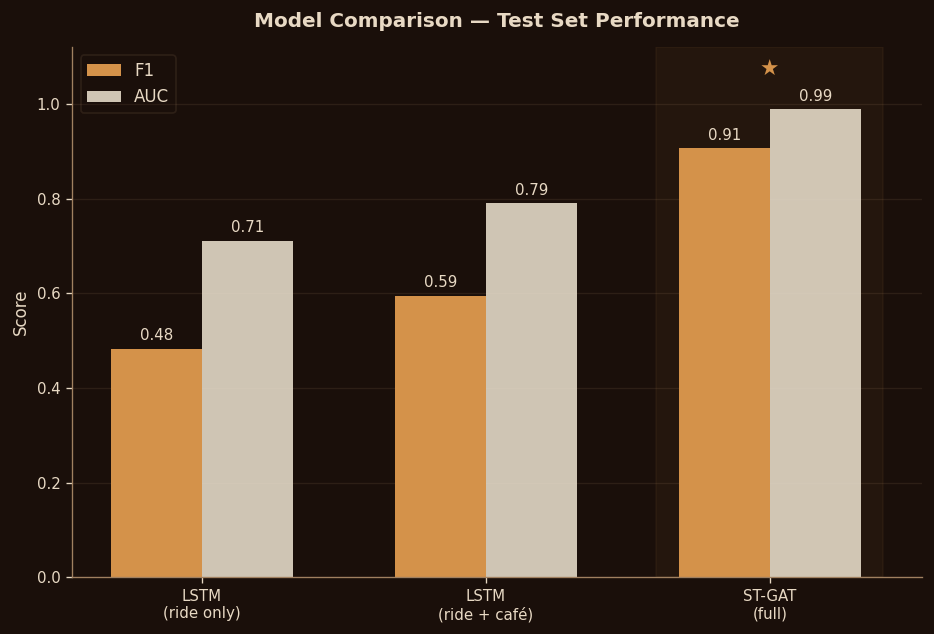

In [6]:
# LSTM baseline metrics (from outputs/model0_outputs and model1_outputs)
LSTM0_F1,  LSTM0_AUC  = 0.482, 0.711
LSTM1_F1,  LSTM1_AUC  = 0.595, 0.790
GAT_F1,    GAT_AUC    = gat["test"]["f1"], gat["test"]["auc"]

models = ["LSTM\n(ride only)", "LSTM\n(ride + café)", "ST-GAT\n(full)"]
f1s    = [LSTM0_F1,  LSTM1_F1,  GAT_F1]
aucs   = [LSTM0_AUC, LSTM1_AUC, GAT_AUC]

x     = np.arange(len(models))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars_f1  = ax.bar(x - width/2, f1s,  width, label="F1",  color=ACCENT, edgecolor="none")
bars_auc = ax.bar(x + width/2, aucs, width, label="AUC", color=CREAM,  edgecolor="none", alpha=0.85)

for bars, vals in [(bars_f1, f1s), (bars_auc, aucs)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=9, color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Model Comparison — Test Set Performance",
             fontsize=12, color=TEXT, fontweight="bold", pad=12)
ax.legend(fontsize=10, framealpha=0.15, labelcolor=TEXT,
          facecolor=BG, edgecolor=SUBTEXT)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_edgecolor(SUBTEXT)
ax.tick_params(labelsize=9)
ax.yaxis.grid(True, alpha=0.15)
ax.set_axisbelow(True)

# Highlight ST-GAT column
ax.axvspan(1.6, 2.4, color=ACCENT, alpha=0.06, zorder=0)
ax.text(2.0, 1.06, "★", ha="center", fontsize=13, color=ACCENT)

fig.tight_layout(pad=1.5)
plt.show()

---
## Figure 5 — Coffee Contribution Index (Diverging Barplot)

The CCI is computed by zero-ablation: for each test day, we run the trained model with and without the café branch and average the probability difference. Positive = café boosts hotspot prediction; negative = café suppresses it.

**Option A** below reads the pre-computed `cci_barplot.png` directly.  
**Option B** reconstructs the barplot from `cci_scores.csv` using the same parameters as `compute_cci.py`.

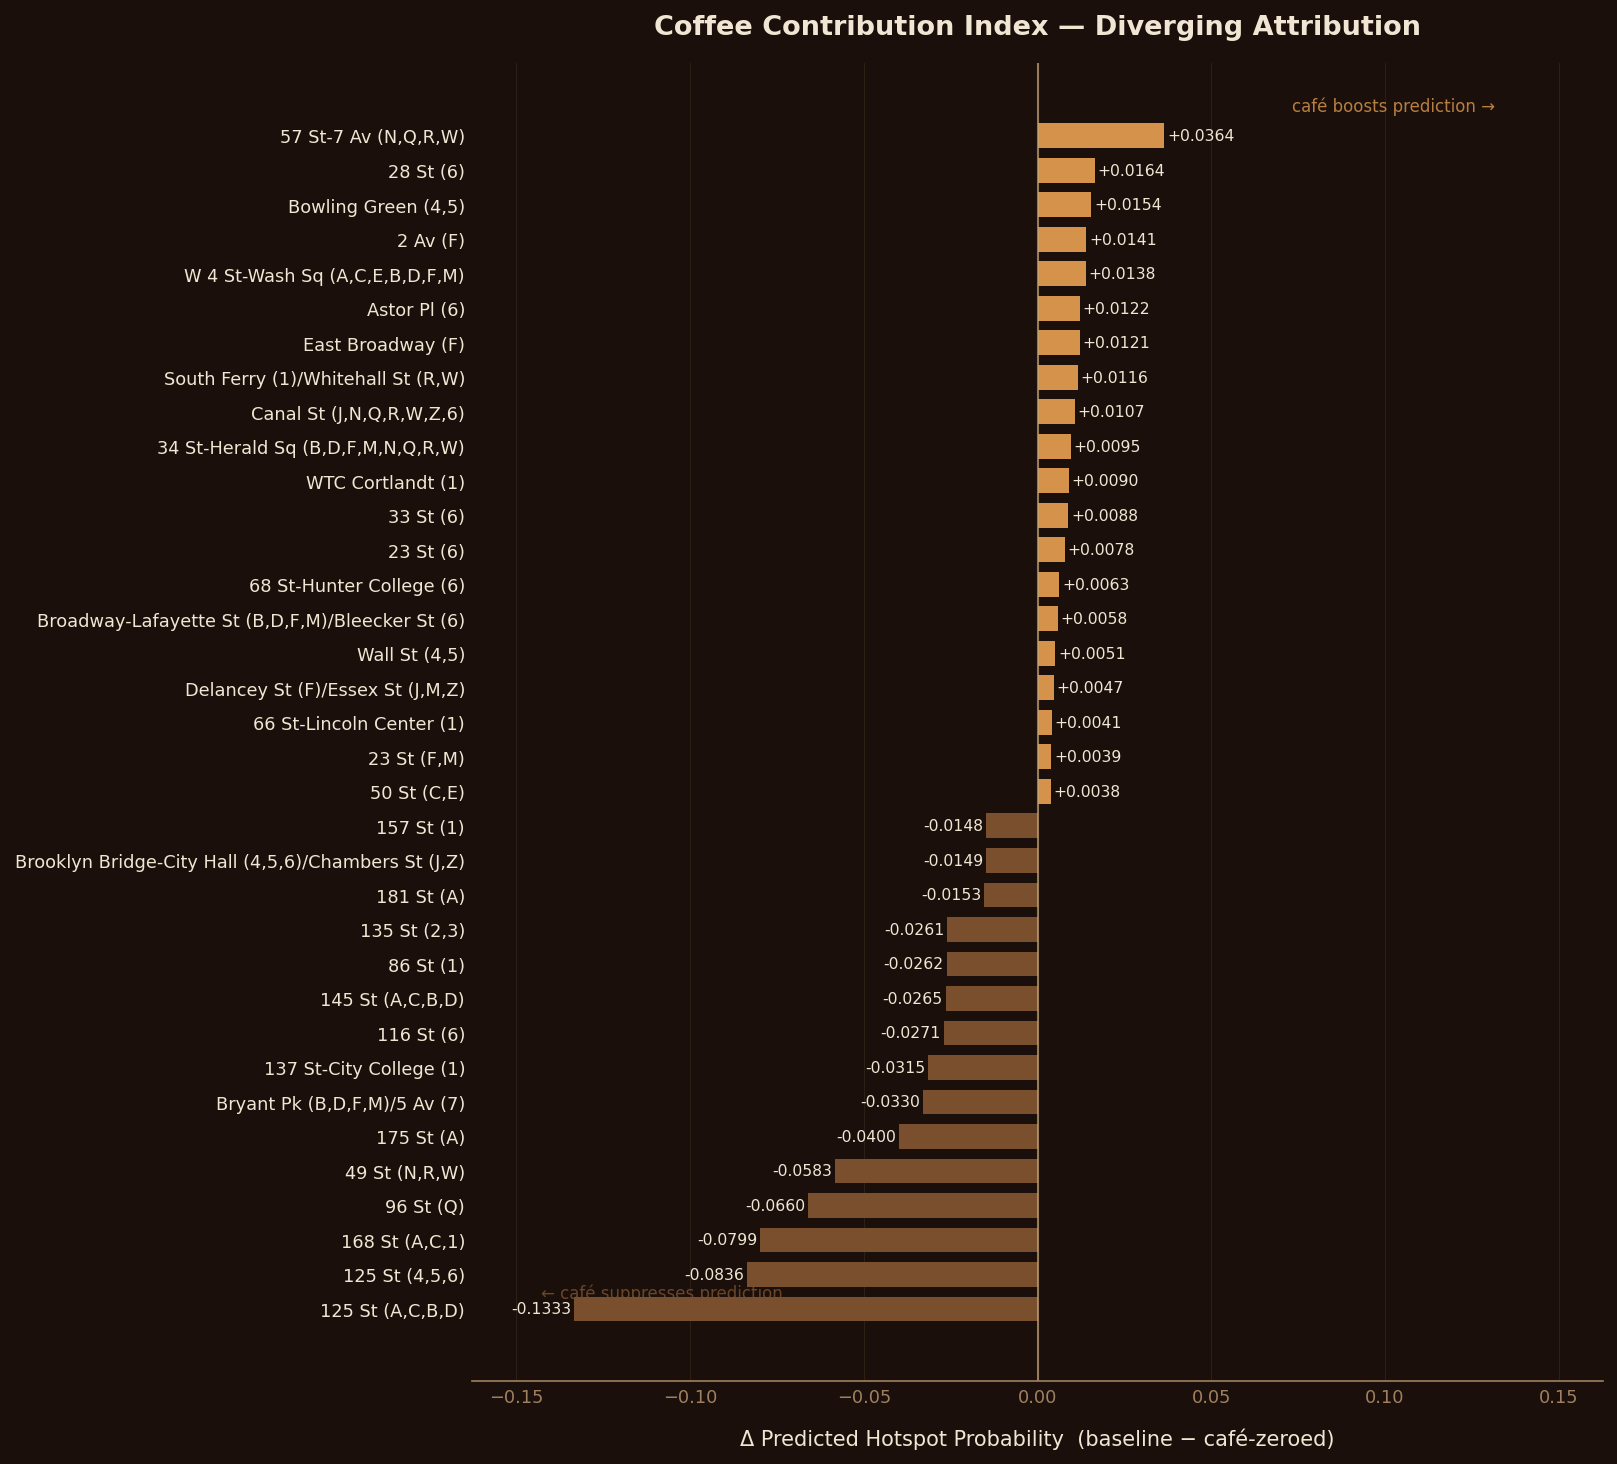

In [7]:
# ── Option A: display the pre-rendered barplot ────────────────────────────────
from IPython.display import Image
Image(CCI_PLOT, width=800)

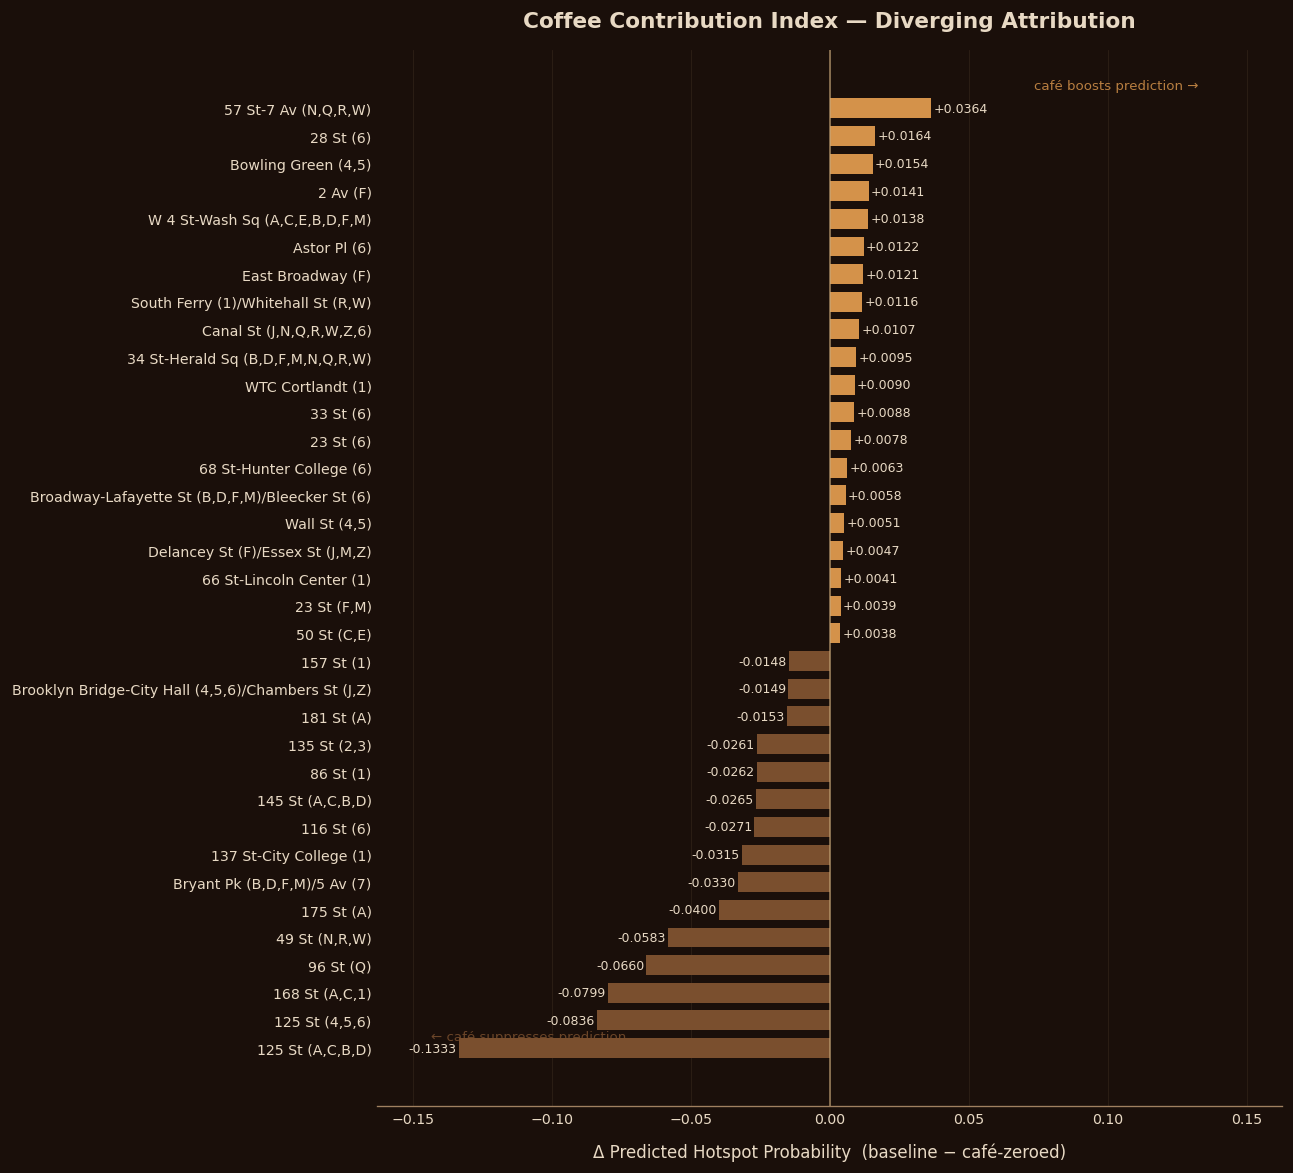


Top 5 positive CCI stations:
  57 St-7 Av (N,Q,R,W)                                     Δprob=+0.03642
  28 St (6)                                                Δprob=+0.01640
  Bowling Green (4,5)                                      Δprob=+0.01539
  2 Av (F)                                                 Δprob=+0.01406
  W 4 St-Wash Sq (A,C,E,B,D,F,M)                           Δprob=+0.01379

Top 5 negative CCI stations:
  49 St (N,R,W)                                            Δprob=-0.05827
  96 St (Q)                                                Δprob=-0.06595
  168 St (A,C,1)                                           Δprob=-0.07992
  125 St (4,5,6)                                           Δprob=-0.08365
  125 St (A,C,B,D)                                         Δprob=-0.13335


In [8]:
# ── Option B: reconstruct from cci_scores.csv ─────────────────────────────────
# (Produces the same chart; useful if cci_barplot.png has been deleted)

ZEROLINE = "#c8a87a"

out = cci.sort_values("cci_raw", ascending=False).reset_index(drop=True)

top_pos = out[out["cci_raw"] > 0].head(20)
top_neg = out[out["cci_raw"] < 0].tail(15)
plot_df = pd.concat([top_neg, top_pos]).sort_values("cci_raw").reset_index(drop=True)

bar_colors = [ACCENT if v >= 0 else MUTED for v in plot_df["cci_raw"]]

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_df["station_name"], plot_df["cci_raw"],
    color=bar_colors, height=0.72, edgecolor="none"
)

ax.axvline(0, color=ZEROLINE, linewidth=1.0, alpha=0.7)

for bar, val in zip(bars, plot_df["cci_raw"]):
    x_off = 0.0008 if val >= 0 else -0.0008
    ha    = "left"  if val >= 0 else "right"
    ax.text(
        val + x_off, bar.get_y() + bar.get_height() / 2,
        f"{val:+.4f}",
        va="center", ha=ha, color=TEXT, fontsize=7.5
    )

xmax = plot_df["cci_raw"].abs().max()
ax.text( xmax * 0.55, len(plot_df) - 0.3, "café boosts prediction →",
         color=ACCENT, fontsize=8, alpha=0.85)
ax.text(-xmax * 0.55, 0.3, "← café suppresses prediction",
         color=MUTED, fontsize=8, ha="right", alpha=0.85)

ax.set_xlabel("Δ Predicted Hotspot Probability  (baseline − café-zeroed)",
              color=TEXT, fontsize=10, labelpad=10)
ax.set_title("Coffee Contribution Index — Diverging Attribution",
             color=TEXT, fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors=TEXT, labelsize=8.5, length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_edgecolor(SUBTEXT)
ax.xaxis.grid(True, color=SUBTEXT, alpha=0.15, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_xlim(-xmax * 1.22, xmax * 1.22)

fig.tight_layout(pad=1.5)
plt.show()

# Summary statistics
print(f"\nTop 5 positive CCI stations:")
for _, r in out.head(5).iterrows():
    print(f"  {r['station_name']:<55}  Δprob={r['cci_raw']:+.5f}")
print(f"\nTop 5 negative CCI stations:")
for _, r in out.tail(5).iterrows():
    print(f"  {r['station_name']:<55}  Δprob={r['cci_raw']:+.5f}")

---
## Saving Figures

Run the cell below to save all figures to `../assets/` (same as running `script/make_figures.py`).

In [9]:
# To regenerate all assets, run make_figures.py from the script directory:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "make_figures.py"],
    cwd=os.path.join(ROOT, "script"),
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Generating figures...
  Saved ../assets/fig1.png
  Saved ../assets/fig2.png
  Saved ../assets/fig3.png
  Saved ../assets/fig4.png
  Copied ../outputs/cci_barplot.png → ../assets/fig5.png

── File check ──────────────────────────────────────────────────
  OK  fig1.png  (105,518 bytes)
  OK  fig2.png  (329,270 bytes)
  OK  fig3.png  (120,721 bytes)
  OK  fig4.png  (39,281 bytes)
  OK  fig5.png  (218,773 bytes)

All figures saved: fig1.png through fig5.png

